# Part 1f: Batch Normalization — TensorFlow & PyTorch

**Objective:** Demonstrate batch normalization and its effect on training speed and stability.

Batch Norm normalizes the input of each layer to have zero mean and unit variance within each mini-batch, then applies a learnable scale (γ) and shift (β).

---

In [1]:
import numpy as np, matplotlib.pyplot as plt, time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32")/255.0, X_test.astype("float32")/255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
X_train_flat, X_test_flat = X_train.reshape(len(X_train),-1), X_test.reshape(len(X_test),-1)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


## TensorFlow: With vs Without Batch Norm

In [2]:
# Without BatchNorm
model_no_bn = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='no_batchnorm')
model_no_bn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
h_no_bn = model_no_bn.fit(X_train_flat, y_train, epochs=30, batch_size=256, validation_split=0.2, verbose=0)
time_no_bn = time.time() - t0

# With BatchNorm — note BN goes BEFORE activation in the recommended pattern
model_bn = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(512), layers.BatchNormalization(), layers.Activation('relu'),
    layers.Dense(256), layers.BatchNormalization(), layers.Activation('relu'),
    layers.Dense(128), layers.BatchNormalization(), layers.Activation('relu'),
    layers.Dense(10, activation='softmax')
], name='with_batchnorm')
model_bn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

t0 = time.time()
h_bn = model_bn.fit(X_train_flat, y_train, epochs=30, batch_size=256, validation_split=0.2, verbose=0)
time_bn = time.time() - t0

print(f"Without BN: val_acc={max(h_no_bn.history['val_accuracy']):.4f}, time={time_no_bn:.1f}s")
print(f"With BN:    val_acc={max(h_bn.history['val_accuracy']):.4f}, time={time_bn:.1f}s")

Without BN: val_acc=0.5215, time=31.6s
With BN:    val_acc=0.4774, time=34.4s


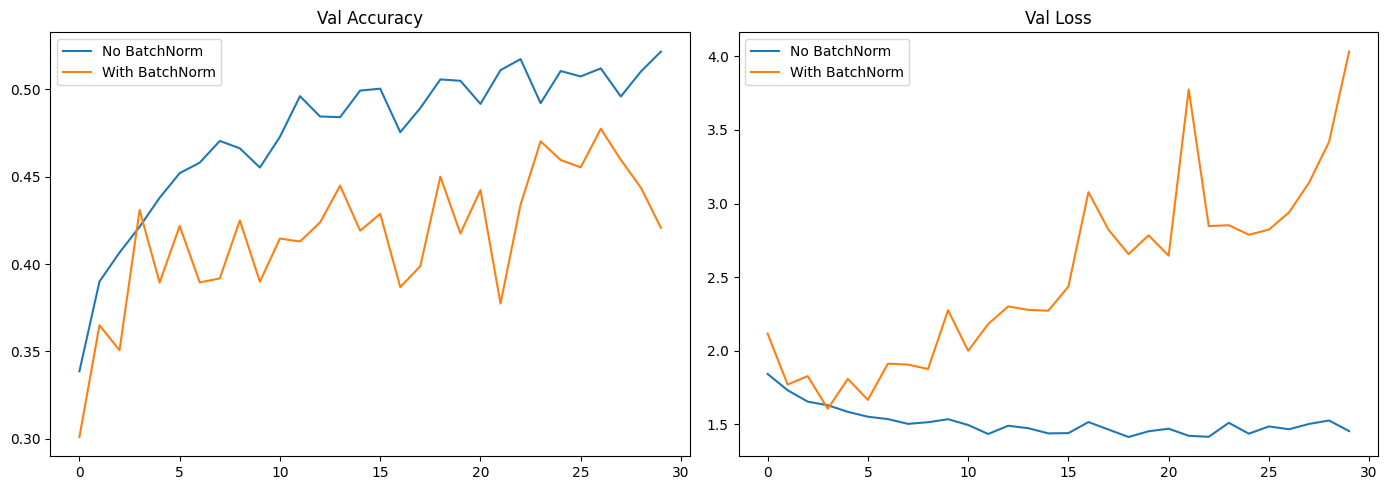

In [3]:
# Comparison plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(h_no_bn.history['val_accuracy'], label='No BatchNorm')
axes[0].plot(h_bn.history['val_accuracy'], label='With BatchNorm')
axes[0].set_title('Val Accuracy'); axes[0].legend()
axes[1].plot(h_no_bn.history['val_loss'], label='No BatchNorm')
axes[1].plot(h_bn.history['val_loss'], label='With BatchNorm')
axes[1].set_title('Val Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

## PyTorch: Batch Normalization

PyTorch No BN: Final acc = 0.5340
PyTorch With BN: Final acc = 0.5175


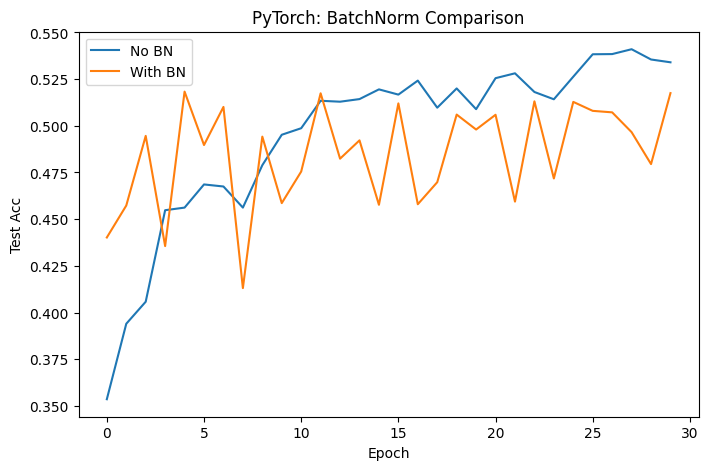

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_flat), torch.LongTensor(y_train)),
                    batch_size=256, shuffle=True)

class NetWithBN(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()
        self.use_bn = use_bn
        self.fc1 = nn.Linear(3072, 512)
        self.bn1 = nn.BatchNorm1d(512) if use_bn else nn.Identity()
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256) if use_bn else nn.Identity()
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128) if use_bn else nn.Identity()
        self.fc4 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.relu(self.bn3(self.fc3(x)))
        return self.fc4(x)

pt_results = {}
for use_bn in [False, True]:
    label = "With BN" if use_bn else "No BN"
    model = NetWithBN(use_bn).to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    accs = []
    for ep in range(30):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            xt = torch.FloatTensor(X_test_flat).to(device)
            accs.append((model(xt).argmax(1)==torch.LongTensor(y_test).to(device)).float().mean().item())
    pt_results[label] = accs
    print(f"PyTorch {label}: Final acc = {accs[-1]:.4f}")

plt.figure(figsize=(8, 5))
for label, accs in pt_results.items(): plt.plot(accs, label=label)
plt.title('PyTorch: BatchNorm Comparison'); plt.legend(); plt.xlabel('Epoch'); plt.ylabel('Test Acc'); plt.show()

## Key Takeaways
- Batch Norm normalizes activations → **faster convergence**, allows higher learning rates
- Acts as mild regularization (noise from mini-batch statistics)
- Place BN **before** activation (Dense → BN → ReLU) for best results
- During inference, BN uses running averages (not batch stats)
- Essential for deep networks (ResNets, etc.)